# First-Pitch Hit-Into-Play Prediction — Global Model Study
## A Single Model Across All Batters, with `batter_id` as a Categorical Feature

This notebook branches from the per-batter multi-batter study. Instead of training 100–200 independent models (one per batter), it trains **one global model per algorithm** across all selected batters combined, using `batter_id` as a native categorical feature.

### Why a global model?
Per-batter models can't share information — a batter with only 120 training PAs gets a model trained on 120 rows, regardless of how many thousands of similar at-bats exist for other batters. A global model pools all data together, letting the model learn general patterns (e.g. "batters who swing at X% of first pitches tend to put Y% into play against pitchers who throw Z") that transfer across batters — especially valuable for batters with limited samples.

### Handling `batter_id` without one-hot sparsity
One-hot encoding 200 batter IDs would add 200 sparse binary columns alongside ~40 existing features — a recipe for overfitting on tree splits and a poor fit for the ANN. Instead:

- **CatBoost** — `batter_id` passed as a native categorical (no encoding). CatBoost's ordered target statistics handle high-cardinality categoricals without sparsity.
- **XGBoost / LightGBM** — both support native categorical features (`enable_categorical=True` for XGBoost; native support in LightGBM), avoiding one-hot.
- **Decision Tree / Random Forest** — sklearn has no native categorical support, so `batter_id` is one-hot encoded for these two only. To offset the added sparsity, three new dense batter-level features (below) give these models a non-sparse way to capture batter identity.
- **ANN** — `batter_id` one-hot encoded (same as Decision Tree/Random Forest). With only ~100-200 categories this is manageable for a dense network, though an embedding layer would be a future improvement.

### New batter-level features
Three season-level batter tendencies are added as dense numeric features:
- `batter_first_pitch_swing_pct`
- `batter_first_pitch_contact_pct`
- `batter_first_pitch_hip_pct`

These are computed once from the **training window only** (static, season-level averages) and give the model a transferable signal about batter tendencies — a low-sample batter with a 50% swing rate behaves more like other 50%-swing-rate batters than like a 20%-swing-rate batter, even if the model has seen little of that specific batter.

**Leakage note**: these are static training-window averages, computed once across the full training period. This carries minor leakage (a batter's HIP% in training is partially derived from the same rows used to train on that batter), but is a reasonable first pass — an expanding/rolling window would eliminate this at the cost of significant additional computation.

---

## 1. Data Ingestion

In [1]:
# ── Imports & Configuration ──────────────────────────────────────────────────
import warnings, sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')

from pybaseball import statcast, cache, playerid_reverse_lookup
cache.enable()
sys.path.insert(0, '.')
from statcast_loader import load_statcast

TRAIN_START  = '2024-03-28'   # Extended back to 2024 for larger training window
TRAIN_END    = '2026-04-15'
VAL_START    = '2026-04-16'
VAL_END      = '2026-06-23'
RANDOM_SEED  = 0
TEST_SIZE    = 0.25
table       = load_statcast(TRAIN_START, TRAIN_END)
table_val   = load_statcast(VAL_START, VAL_END)
table_full  = load_statcast(TRAIN_START, VAL_END)   # pitcher stats drawn from full window

table['pitch_id']      = table.index
table_val['pitch_id']  = table_val.index
table_full['pitch_id'] = table_full.index

print(f'Training data  : {len(table):,} pitches  ({TRAIN_START} to {TRAIN_END})')
print(f'Validation data: {len(table_val):,} pitches  ({VAL_START} to {VAL_END})')

Loading from cache: statcast_20240328_20260415.parquet  (220.5 MB)
Loaded 1,614,292 pitches  (2024-03-28 → 2026-04-15)
Loading from cache: statcast_20260416_20260623.parquet  (37.4 MB)
Loaded 267,896 pitches  (2026-04-16 → 2026-06-23)
Loading from cache: statcast_20240328_20260623.parquet  (254.5 MB)
Loaded 1,882,188 pitches  (2024-03-28 → 2026-06-23)
Training data  : 1,614,292 pitches  (2024-03-28 to 2026-04-15)
Validation data: 267,896 pitches  (2026-04-16 to 2026-06-23)


In [2]:
# ── Load Sequential Context Features from Sidecar Parquets ──────────────────
# Generate these files once with:
#   python build_context_features.py <training_parquet>
#   python build_context_features.py <validation_parquet>
#
# Columns added:
#   pitcher_pitch_count_in_game     — pitches thrown by pitcher BEFORE this pitch
#   batter_prior_hip_count_in_game  — first-pitch HIPs by batter BEFORE this AB
#   pitcher_pitch_count_prior_game  — pitcher's total pitches in their prior game
#   batter_prior_game_hip_count     — batter's first-pitch HIPs in their prior game
CONTEXT_COLS  = ['pitcher_pitch_count_in_game', 'batter_prior_hip_count_in_game',
                 'pitcher_pitch_count_prior_game', 'batter_prior_game_hip_count']
TRAIN_CONTEXT = f'statcast_{TRAIN_START.replace("-","")}_{TRAIN_END.replace("-","")}_context_features.parquet'
VAL_CONTEXT   = f'statcast_{VAL_START.replace("-","")}_{VAL_END.replace("-","")}_context_features.parquet'

if os.path.exists(TRAIN_CONTEXT):
    ctx_train = pd.read_parquet(TRAIN_CONTEXT)
    table = table.drop(columns=[c for c in CONTEXT_COLS if c in table.columns], errors='ignore')
    table = table.merge(ctx_train, on='pitch_id', how='left')
    for col in CONTEXT_COLS:
        if col in table.columns:
            table[col] = table[col].fillna(0).astype(int)
        else:
            table[col] = 0
            print(f'  NOTE: {col} not in sidecar — set to 0. Regenerate sidecar.')
    print(f'Training context features loaded: {len(ctx_train):,} rows')
else:
    print(f'WARNING: {TRAIN_CONTEXT} not found — running without context features.')
    for col in CONTEXT_COLS:
        table[col] = 0

if os.path.exists(VAL_CONTEXT):
    ctx_val = pd.read_parquet(VAL_CONTEXT)
    table_val = table_val.drop(columns=[c for c in CONTEXT_COLS if c in table_val.columns], errors='ignore')
    table_val = table_val.merge(ctx_val, on='pitch_id', how='left')
    for col in CONTEXT_COLS:
        if col in table_val.columns:
            table_val[col] = table_val[col].fillna(0).astype(int)
        else:
            table_val[col] = 0
            print(f'  NOTE: {col} not in sidecar — set to 0. Regenerate sidecar.')
    print(f'Validation context features loaded: {len(ctx_val):,} rows')
else:
    print(f'WARNING: {VAL_CONTEXT} not found — running without context features.')
    for col in CONTEXT_COLS:
        table_val[col] = 0

table['pitch_id']     = table.index
table_val['pitch_id'] = table_val.index

print(f'Context cols on table     : {[c for c in CONTEXT_COLS if c in table.columns]}')
print(f'Context cols on table_val : {[c for c in CONTEXT_COLS if c in table_val.columns]}')

Training context features loaded: 1,614,292 rows
Validation context features loaded: 267,896 rows
Context cols on table     : ['pitcher_pitch_count_in_game', 'batter_prior_hip_count_in_game', 'pitcher_pitch_count_prior_game', 'batter_prior_game_hip_count']
Context cols on table_val : ['pitcher_pitch_count_in_game', 'batter_prior_hip_count_in_game', 'pitcher_pitch_count_prior_game', 'batter_prior_game_hip_count']


## 2. Identify Top 300 Batters by First-Pitch Hit-Into-Play Rate (min. 100 PA)

In [3]:
# ── Selection criteria ───────────────────────────────────────────────────────
MIN_PA        = 100   # minimum first-pitch PA to qualify
TOP_N_BATTERS = 300

first_pitch_train = table[(table['balls'] == 0) & (table['strikes'] == 0)]
first_pitch_val   = table_val[(table_val['balls'] == 0) & (table_val['strikes'] == 0)]
first_pitch_full  = table_full[(table_full['balls'] == 0) & (table_full['strikes'] == 0)]

# Per-batter PA count and HIP count in training window
pa_counts  = first_pitch_train['batter'].value_counts()
hip_counts = (
    first_pitch_train[first_pitch_train['description'] == 'hit_into_play']
    ['batter'].value_counts()
)

# Build HIP rate table, enforce minimum PA, require presence in validation window
val_batters = set(first_pitch_val['batter'].unique())
hip_rate_df = (
    pd.DataFrame({'pa': pa_counts, 'hip': hip_counts})
    .fillna(0)
    .astype({'pa': int, 'hip': int})
    .assign(hip_rate=lambda df: df['hip'] / df['pa'])
    .loc[lambda df: (df['pa'] >= MIN_PA) & df.index.isin(val_batters)]
    .sort_values('hip_rate', ascending=False)
)

top_batter_ids = list(hip_rate_df.head(TOP_N_BATTERS).index)

print(f'Batters meeting criteria (>= {MIN_PA} PA, present in validation): {len(hip_rate_df):,}')
print(f'Top {TOP_N_BATTERS} selected.')
print(f'HIP rate range: {hip_rate_df["hip_rate"].iloc[len(top_batter_ids)-1]:.3f} '
      f'– {hip_rate_df["hip_rate"].iloc[0]:.3f}')

# ── Build batter name map via reverse lookup ──────────────────────────────────
lookup_df = playerid_reverse_lookup(top_batter_ids, key_type='mlbam')
name_map  = {
    int(row['key_mlbam']): f"{row['name_first'].title()} {row['name_last'].title()}"
    for _, row in lookup_df.iterrows()
}

print(f'\n{len(top_batter_ids)} batters selected for global model.')

Batters meeting criteria (>= 100 PA, present in validation): 451
Top 300 selected.
HIP rate range: 0.101 – 0.203

300 batters selected for global model.


## 3. Shared Feature-Engineering Constants

In [4]:
# ── All constants used in feature engineering ────────────────────────────────
NOT_IN_PLAY_OUTCOMES = [
    'called_strike', 'foul', 'swinging_strike', 'swinging_strike_blocked',
    'foul_tip', 'foul_bunt', 'missed_bunt', 'blocked_ball', 'ball',
    'bunt_foul_tip', 'automatic_strike', 'automatic_ball', 'intent_ball',
    'pitchout', 'hit_by_pitch',
]

PITCH_TYPES = ['FF','SI','SL','CH','FC','ST','CU','FS','KC','None',
               'SV','KN','FA','EP','FO','CS','SC','PO','UN']

pitcher_cols = (
    ['pitcher', 'strike_percent', 'swing_percent_on_strikes',
     'contact_percent_on_strikes', 'in_play_percent_on_strikes']
    + [f'{pt}_percent' for pt in PITCH_TYPES]
)

DROP_COLS_1 = [
    'game_date','spin_dir','batter','zone','spin_axis','spin_rate_deprecated',
    'break_angle_deprecated','break_length_deprecated','des','game_type','type',
    'hit_location','bb_type','balls','strikes','game_year','hc_x','hc_y',
    'tfs_deprecated','tfs_zulu_deprecated','umpire','sv_id','player_name',
    'hit_distance_sc','launch_speed','launch_angle',
    'fielder_2','fielder_3','fielder_4','fielder_5','fielder_6','fielder_7','fielder_8','fielder_9',
    'home_team','away_team','home_score','away_score','bat_score','fld_score',
    'post_away_score','post_home_score','post_bat_score','post_fld_score',
    'release_pos_y','delta_home_win_exp','delta_run_exp','bat_speed','swing_length',
    'estimated_slg_using_speedangle','delta_pitcher_run_exp','hyper_speed',
    'home_score_diff','home_win_exp','age_pit_legacy','age_bat_legacy',
    'age_pit','age_bat','pitcher_days_since_prev_game','batter_days_since_prev_game',
    'pitcher_days_until_next_game','batter_days_until_next_game','pitch_name',
]
DROP_COLS_2 = [
    'if_fielding_alignment','of_fielding_alignment','pitch_type','release_speed',
    'release_pos_x','release_pos_z','vx0','vy0','vz0','ax','ay','az','sz_top',
    'effective_speed','release_spin_rate','release_extension','sz_bot','pfx_x','pfx_z',
    'arm_angle','plate_x','plate_z','api_break_z_with_gravity','api_break_x_arm',
    'api_break_x_batter_in','estimated_ba_using_speedangle','estimated_woba_using_speedangle',
    'woba_value','woba_denom','babip_value','iso_value','launch_speed_angle',
]
DROP_COLS_3 = [
    'bat_score_diff','n_thruorder_pitcher','n_priorpa_thisgame_player_at_bat',
    'attack_angle','attack_direction','swing_path_tilt',
    'intercept_ball_minus_batter_pos_x_inches','intercept_ball_minus_batter_pos_y_inches', 'miss_distance',
]

# NOTE: batter_id retained as a feature for the global model (unlike per-batter
# notebook, where 'batter' was dropped via DROP_COLS_1 because every row was
# the same batter). Remove 'batter' from DROP_COLS_1 here.
DROP_COLS_1.remove('batter')

CATEGORICAL_COLS_TREE = ['p_throws', 'outs_when_up', 'stand', 'prev_pitch_result', 'batter']
CATEGORICAL_COLS_NATIVE = ['p_throws', 'outs_when_up', 'stand', 'prev_pitch_result']  # batter_id passed separately
DROP_BEFORE_MODEL = ['pitcher', 'game_pk', 'inning', 'inning_topbot', 'pitch_number', 'pitch_id']

EVENT_MAP = {
    'hit_by_pitch': 'walk',    'intent_walk': 'walk',    'catcher_interf': 'walk',
    'home_run': 'extra_base_hit', 'triple': 'extra_base_hit', 'double': 'extra_base_hit',
    'force_out': 'field_out',  'fielders_choice': 'field_out',  'grounded_into_double_play': 'field_out',
    'double_play': 'field_out', 'fielders_choice_out': 'field_out', 'sac_bunt': 'field_out',
    'sac_fly': 'field_out',    'field_error': 'single',
    'strikeout_double_play': 'strikeout',
}

MODEL_NAMES = ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'ANN']

print('Constants defined.')
print(f"'batter' removed from DROP_COLS_1: {'batter' not in DROP_COLS_1}")

Constants defined.
'batter' removed from DROP_COLS_1: True


## 4. Helper Functions

In [5]:
# ── Feature engineering helpers ───────────────────────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

def compute_pitch_counts(desc_series):
    vc = desc_series.value_counts()
    return {k: vc.get(k, 0) for k in
            ['ball','called_strike','swinging_strike','foul','foul_bunt',
             'hit_into_play','blocked_ball','foul_tip','bunt_foul_tip',
             'swinging_strike_blocked','hit_by_pitch','missed_bunt',
             'pitchout','automatic_strike','automatic_ball','intent_ball']}

def build_pitcher_features(rows, source_first_pitch):
    """Build pitcher feature DataFrame for pitchers appearing in `rows`."""
    pitchers = rows['pitcher'].unique()
    pdf = pd.DataFrame(pitchers, columns=['pitcher'])
    for col in pitcher_cols[1:]:
        pdf[col] = 0.0
    for i in range(len(pdf)):
        pid = pdf['pitcher'].iloc[i]
        sel = source_first_pitch[source_first_pitch['pitcher'] == pid]
        c   = compute_pitch_counts(sel['description'])
        total_p   = sum(c.values())
        t_strikes = (c['called_strike'] + c['swinging_strike'] + c['foul'] +
                     c['foul_bunt'] + c['hit_into_play'] + c['foul_tip'] +
                     c['swinging_strike_blocked'] + c['missed_bunt'] +
                     c['bunt_foul_tip'] + c['automatic_strike'])
        t_contact = c['foul'] + c['foul_bunt'] + c['hit_into_play'] + c['foul_tip'] + c['bunt_foul_tip']
        t_swings  = (c['swinging_strike'] + c['swinging_strike_blocked'] +
                     c['foul'] + c['foul_bunt'] + c['hit_into_play'] + c['foul_tip'] + c['bunt_foul_tip'])
        if total_p > 0:
            pdf.at[i, 'strike_percent'] = t_strikes / total_p
            if t_strikes > 0:
                pdf.at[i, 'swing_percent_on_strikes']  = t_swings  / t_strikes
                pdf.at[i, 'contact_percent_on_strikes'] = t_contact / t_strikes
                pdf.at[i, 'in_play_percent_on_strikes'] = c['hit_into_play'] / t_strikes
        sel_pt   = sel['pitch_type'].fillna('None')
        pt_vc    = sel_pt.value_counts()
        total_pt = pt_vc.sum()
        if total_pt > 0:
            for pt in PITCH_TYPES:
                pdf.at[i, f'{pt}_percent'] = pt_vc.get(pt, 0) / total_pt
    return pdf

def build_batter_features(batter_ids, source_first_pitch):
    """
    Build batter-level tendency features (static, training-window averages):
      batter_first_pitch_swing_pct   — % of first pitches swung at
      batter_first_pitch_contact_pct — % of SWINGS that made contact
      batter_first_pitch_hip_pct     — % of first pitches resulting in hit_into_play
    """
    SWING_SET   = {'swinging_strike','swinging_strike_blocked','foul','foul_bunt',
                   'hit_into_play','foul_tip','bunt_foul_tip','missed_bunt'}
    CONTACT_SET = {'foul','foul_bunt','hit_into_play','foul_tip','bunt_foul_tip'}

    bdf = pd.DataFrame(batter_ids, columns=['batter'])
    bdf['batter_first_pitch_swing_pct']   = 0.0
    bdf['batter_first_pitch_contact_pct'] = 0.0
    bdf['batter_first_pitch_hip_pct']     = 0.0

    for i in range(len(bdf)):
        bid = bdf['batter'].iloc[i]
        sel = source_first_pitch[source_first_pitch['batter'] == bid]
        n   = len(sel)
        if n == 0:
            continue
        desc       = sel['description']
        n_swing    = desc.isin(SWING_SET).sum()
        n_contact  = desc.isin(CONTACT_SET).sum()
        n_hip      = (desc == 'hit_into_play').sum()

        bdf.at[i, 'batter_first_pitch_swing_pct']   = n_swing / n
        bdf.at[i, 'batter_first_pitch_contact_pct'] = (n_contact / n_swing) if n_swing > 0 else 0.0
        bdf.at[i, 'batter_first_pitch_hip_pct']     = n_hip / n
    return bdf

def add_game_state_context(merged_df, clean_df, source_table):
    """Add prev_pitch_result and prev_ab_pitch_count columns."""
    merged_df = merged_df.copy()
    merged_df['prev_pitch_result']   = ''
    merged_df['prev_ab_pitch_count'] = 0
    for i in range(len(clean_df)):
        select_id   = clean_df['pitch_id'].iloc[i]
        select_game = merged_df['game_pk'].iloc[i]
        select_inn  = merged_df['inning'].iloc[i]
        select_top  = merged_df['inning_topbot'].iloc[i]
        prev = source_table[source_table['pitch_id'] == (select_id + 1)]
        if prev.empty:
            merged_df.at[i, 'prev_pitch_result'] = 'start_of_game'
            continue
        prev_game = prev['game_pk'].values[0]
        prev_inn  = prev['inning'].values[0]
        prev_top  = prev['inning_topbot'].values[0]
        if prev_game != select_game:
            merged_df.at[i, 'prev_pitch_result'] = 'start_of_game'
        elif prev_inn != select_inn or prev_top != select_top:
            merged_df.at[i, 'prev_pitch_result'] = 'start_of_inning'
        else:
            merged_df.at[i, 'prev_pitch_result']   = prev['events'].values[0]
            merged_df.at[i, 'prev_ab_pitch_count'] = prev['pitch_number'].values[0]
    merged_df.replace(EVENT_MAP, inplace=True)
    desc_col = merged_df.pop('description')
    merged_df.insert(len(merged_df.columns), 'description', desc_col)
    return merged_df

def clean_columns(rows):
    """Drop irrelevant columns and binarise base-runner flags. Keeps 'batter'."""
    clean = (
        rows
        .drop(columns=DROP_COLS_1, errors='ignore')
        .drop(columns=DROP_COLS_2, errors='ignore')
        .drop(columns=DROP_COLS_3, errors='ignore')
    )
    for base_col in ['on_1b', 'on_2b', 'on_3b']:
        clean[base_col] = clean[base_col].fillna(0)
        clean.loc[clean[base_col] > 0, base_col] = 1
    return clean

def minority_class_metrics(y_true, y_pred, minority_label=1):
    """Return precision, recall, F1 specifically for the minority class."""
    prec = precision_score(y_true, y_pred, pos_label=minority_label, zero_division=0)
    rec  = recall_score(y_true, y_pred,    pos_label=minority_label, zero_division=0)
    f1   = f1_score(y_true, y_pred,        pos_label=minority_label, zero_division=0)
    return prec, rec, f1

print('Helper functions defined.')

Helper functions defined.


## 5. Install & Import Model Packages

In [6]:
import subprocess, sys, platform

# LightGBM
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lightgbm', '--quiet'])
# XGBoost (macOS requires libomp via conda: conda install -c conda-forge libomp)
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '--quiet'])
# CatBoost
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'catboost', '--quiet'])

import tensorflow as tf
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

print('All model packages ready.')
print(f'TensorFlow: {tf.__version__}')

All model packages ready.
TensorFlow: 2.18.0


## 6. Build Combined Dataset Across All Batters

Unlike the per-batter notebook, this section builds **one combined feature matrix** spanning all 200 selected batters for training, and a separate combined matrix for validation. Each row retains its `batter` ID as a feature.

Steps per batter:
1. Label outcomes (`hit_into_play` vs `not_in_play`)
2. Compute decay weights based on `game_date`
3. Build pitcher features (same as per-batter notebook)
4. Add game-state context (`prev_pitch_result`, `prev_ab_pitch_count`)

After all batters are processed, the three batter-level tendency features (`batter_first_pitch_swing_pct`, `batter_first_pitch_contact_pct`, `batter_first_pitch_hip_pct`) are computed once from the full training set and merged onto every row by `batter` ID.

In [7]:
# ── Decay weight parameters ───────────────────────────────────────────────────
DECAY_RATE   = 0.004
TRAIN_END_DT = pd.Timestamp(TRAIN_END)

def build_combined_dataset(batter_ids, first_pitch_source, full_pitcher_source,
                            source_table, label, compute_weights=False):
    """
    Build a combined feature matrix across multiple batters.
    Returns (merged_df, weights_array or None, skipped_list).
    """
    all_merged  = []
    all_weights = []
    skipped_local = []

    for idx, bid in enumerate(batter_ids):
        bname = name_map.get(int(bid), str(bid))
        rows = first_pitch_source[first_pitch_source['batter'] == bid].copy()
        if len(rows) < 5:
            skipped_local.append((bid, bname, f'{label}: only {len(rows)} rows'))
            continue

        labeled = rows.drop('events', axis=1)
        for outcome in NOT_IN_PLAY_OUTCOMES:
            labeled = labeled.replace(outcome, 'not_in_play')

        # Only skip for missing hit_into_play in TRAINING — validation batters
        # with no HIP in the validation window are still valid and should be scored
        if label == 'train' and 'hit_into_play' not in labeled['description'].values:
            skipped_local.append((bid, bname, f'{label}: no hit_into_play'))
            continue

        if compute_weights:
            raw_dates = pd.to_datetime(labeled['game_date'], errors='coerce')
            days_ago  = (TRAIN_END_DT - raw_dates).dt.days.clip(lower=0).fillna(0)
            # Key weights by pitch_id (stable across merges), not positional index
            weight_by_pitch_id = pd.Series(
                np.exp(-DECAY_RATE * days_ago).values,
                index=labeled['pitch_id'].values
            )

        pitcher_feats = build_pitcher_features(labeled, full_pitcher_source)
        clean         = clean_columns(labeled)
        merged        = pd.merge(clean, pitcher_feats, on='pitcher', how='inner')
        merged        = add_game_state_context(merged, clean, source_table)

        if compute_weights:
            # merged retains 'pitch_id' (not dropped until DROP_BEFORE_MODEL later)
            aligned_weights = (
                weight_by_pitch_id.reindex(merged['pitch_id'].values)
                .fillna(weight_by_pitch_id.mean())
                .values
            )
            all_weights.append(aligned_weights)

        all_merged.append(merged)

        if (idx + 1) % 25 == 0 or (idx + 1) == len(batter_ids):
            print(f'  [{label}] processed {idx+1}/{len(batter_ids)} batters...')

    combined = pd.concat(all_merged, ignore_index=True)
    weights  = np.concatenate(all_weights) if compute_weights else None
    return combined, weights, skipped_local

print('Building combined TRAINING dataset...')
train_combined, train_weights, skipped_train = build_combined_dataset(
    top_batter_ids, first_pitch_train, first_pitch_train, table,
    label='train', compute_weights=True
)
print(f'\nTraining combined shape: {train_combined.shape}')
print(f'Skipped (train): {len(skipped_train)}')

print('\nBuilding combined VALIDATION dataset...')
val_combined, _, skipped_val = build_combined_dataset(
    top_batter_ids, first_pitch_val, first_pitch_full, table_val,
    label='val', compute_weights=False
)
print(f'\nValidation combined shape: {val_combined.shape}')
print(f'Skipped (val): {len(skipped_val)}')

skipped = skipped_train + skipped_val

Building combined TRAINING dataset...
  [train] processed 25/300 batters...
  [train] processed 50/300 batters...
  [train] processed 75/300 batters...
  [train] processed 100/300 batters...
  [train] processed 125/300 batters...
  [train] processed 150/300 batters...
  [train] processed 175/300 batters...
  [train] processed 200/300 batters...
  [train] processed 225/300 batters...
  [train] processed 250/300 batters...
  [train] processed 275/300 batters...
  [train] processed 300/300 batters...

Training combined shape: (226968, 45)
Skipped (train): 0

Building combined VALIDATION dataset...
  [val] processed 25/300 batters...
  [val] processed 50/300 batters...
  [val] processed 75/300 batters...
  [val] processed 100/300 batters...
  [val] processed 125/300 batters...
  [val] processed 150/300 batters...
  [val] processed 175/300 batters...
  [val] processed 200/300 batters...
  [val] processed 225/300 batters...
  [val] processed 250/300 batters...
  [val] processed 275/300 batte

In [8]:
# ── Add batter-level tendency features ───────────────────────────────────────
# Computed ONCE from the full training set (static season-level averages),
# then merged onto both train and validation by batter ID.
batter_feats = build_batter_features(top_batter_ids, first_pitch_train)

train_combined = train_combined.merge(batter_feats, on='batter', how='left')
val_combined   = val_combined.merge(batter_feats,   on='batter', how='left')

BATTER_LEVEL_COLS = ['batter_first_pitch_swing_pct', 'batter_first_pitch_contact_pct',
                     'batter_first_pitch_hip_pct']
for col in BATTER_LEVEL_COLS:
    train_combined[col] = train_combined[col].fillna(0.0)
    val_combined[col]   = val_combined[col].fillna(0.0)

print('Batter-level features added:')
print(train_combined[BATTER_LEVEL_COLS].describe().round(3).to_string())

Batter-level features added:
       batter_first_pitch_swing_pct  batter_first_pitch_contact_pct  batter_first_pitch_hip_pct
count                    226968.000                      226968.000                  226968.000
mean                          0.356                           0.762                       0.130
std                           0.064                           0.062                       0.021
min                           0.197                           0.569                       0.101
25%                           0.312                           0.716                       0.115
50%                           0.356                           0.759                       0.126
75%                           0.399                           0.802                       0.144
max                           0.558                           0.934                       0.203


## 7. Encoding — Two Paths for `batter_id`

**Native-categorical path** (CatBoost, XGBoost, LightGBM): `p_throws`, `outs_when_up`, `stand`, `prev_pitch_result`, and `batter` are passed as categorical dtype columns directly to the model — no one-hot encoding, no sparsity.

**One-hot path** (Decision Tree, Random Forest, ANN): all five categorical columns including `batter` are one-hot encoded via `ColumnTransformer`. With 200 batter categories this adds ~200 sparse columns; the three batter-level dense features added in Section 6 help offset this.

In [9]:
# ── Split into X / y for both train and validation ───────────────────────────
# NOTE: select 'description' (target) explicitly by name rather than by
# position — the batter-level feature merge in Section 6 appended new
# columns AFTER 'description', so it is no longer the last column.
train_dataset = train_combined.drop(columns=DROP_BEFORE_MODEL, errors='ignore')
val_dataset   = val_combined.drop(columns=DROP_BEFORE_MODEL, errors='ignore')

y_train_raw = train_dataset['description']
X_train_raw = train_dataset.drop(columns=['description'])
y_val_raw   = val_dataset['description']
X_val_raw   = val_dataset.drop(columns=['description'])

print(f'X_train_raw: {X_train_raw.shape}   X_val_raw: {X_val_raw.shape}')
print(f'Columns: {list(X_train_raw.columns)}')

X_train_raw: (226968, 41)   X_val_raw: (42563, 41)
Columns: ['batter', 'stand', 'p_throws', 'on_3b', 'on_2b', 'on_1b', 'outs_when_up', 'at_bat_number', 'bat_win_exp', 'pitcher_pitch_count_in_game', 'batter_prior_hip_count_in_game', 'pitcher_pitch_count_prior_game', 'batter_prior_game_hip_count', 'strike_percent', 'swing_percent_on_strikes', 'contact_percent_on_strikes', 'in_play_percent_on_strikes', 'FF_percent', 'SI_percent', 'SL_percent', 'CH_percent', 'FC_percent', 'ST_percent', 'CU_percent', 'FS_percent', 'KC_percent', 'None_percent', 'SV_percent', 'KN_percent', 'FA_percent', 'EP_percent', 'FO_percent', 'CS_percent', 'SC_percent', 'PO_percent', 'UN_percent', 'prev_pitch_result', 'prev_ab_pitch_count', 'batter_first_pitch_swing_pct', 'batter_first_pitch_contact_pct', 'batter_first_pitch_hip_pct']


In [10]:
# ── NATIVE-CATEGORICAL PATH (CatBoost, XGBoost, LightGBM) ─────────────────────
# batter_id and other categoricals kept as categorical dtype — no encoding
X_train_native = X_train_raw.copy()
X_val_native   = X_val_raw.copy()

# Cast to string FIRST — XGBoost's categorical support (enable_categorical)
# requires string category labels; integer batter IDs as categories
# trigger 'object of type int has no len()' inside XGBoost's validation.
for col in CATEGORICAL_COLS_NATIVE + ['batter']:
    X_train_native[col] = X_train_native[col].astype(str).astype('category')
    train_categories = list(X_train_native[col].cat.categories)

    val_col = X_val_native[col].astype(str)
    unseen  = ~val_col.isin(train_categories)
    if unseen.any():
        fallback = train_categories[0]
        print(f'  {col}: {unseen.sum()} validation rows with unseen '
              f'categories -> mapped to {fallback!r}')
        val_col.loc[unseen] = fallback

    X_val_native[col] = pd.Categorical(val_col, categories=train_categories)

le_native = LabelEncoder()
y_train_native = le_native.fit_transform(y_train_raw)
y_val_native   = le_native.transform(y_val_raw)

classes_native  = list(le_native.classes_)
minority_native = classes_native.index('hit_into_play')

cat_feature_idx = [X_train_native.columns.get_loc(c) for c in CATEGORICAL_COLS_NATIVE + ['batter']]

print(f'Native-categorical X_train: {X_train_native.shape}')
print(f'Categorical feature indices: {cat_feature_idx}')
print(f'Minority label (hit_into_play): {minority_native}')

Native-categorical X_train: (226968, 41)
Categorical feature indices: [2, 6, 1, 36, 0]
Minority label (hit_into_play): 0


In [11]:
# ── ONE-HOT PATH (Decision Tree, Random Forest, ANN) ──────────────────────────
ct_onehot = ColumnTransformer(
    transformers=[('enc', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_COLS_TREE)],
    remainder='passthrough'
)
X_train_oh = ct_onehot.fit_transform(X_train_raw)
X_val_oh   = ct_onehot.transform(X_val_raw)

le_oh = LabelEncoder()
y_train_oh = le_oh.fit_transform(y_train_raw)
y_val_oh   = le_oh.transform(y_val_raw)

classes_oh  = list(le_oh.classes_)
minority_oh = classes_oh.index('hit_into_play')

print(f'One-hot X_train: {X_train_oh.shape}  (sparsity from {len(top_batter_ids)} batter categories)')
print(f'Minority label (hit_into_play): {minority_oh}')

One-hot X_train: (226968, 351)  (sparsity from 300 batter categories)
Minority label (hit_into_play): 0


In [12]:
# ── SMOTE + weight propagation (one-hot path only — tree-native path uses
#    class-balancing parameters instead, since SMOTE requires numeric input) ──
n_orig_oh = X_train_oh.shape[0]
X_sm_oh, y_sm_oh = SMOTE(sampling_strategy='minority', random_state=42).fit_resample(
    X_train_oh, y_train_oh
)
n_synth_oh = X_sm_oh.shape[0] - n_orig_oh

minority_mask_oh   = (y_train_oh == minority_oh)
mean_minority_w_oh = train_weights[minority_mask_oh].mean() if minority_mask_oh.any() else 1.0
sm_weights_oh = np.concatenate([
    train_weights,
    np.full(n_synth_oh, mean_minority_w_oh),
])

X_tr_oh, X_te_oh, y_tr_oh, y_te_oh, w_tr_oh, w_te_oh = train_test_split(
    X_sm_oh, y_sm_oh, sm_weights_oh, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

sc_oh = StandardScaler(with_mean=False)   # with_mean=False for sparse matrices
X_tr_oh = sc_oh.fit_transform(X_tr_oh)
X_te_oh = sc_oh.transform(X_te_oh)
X_val_oh_sc = sc_oh.transform(X_val_oh)

print(f'One-hot path: {X_sm_oh.shape[0]} samples after SMOTE '
      f'({n_orig_oh} real + {n_synth_oh} synthetic)')

One-hot path: 394762 samples after SMOTE (226968 real + 167794 synthetic)


In [13]:
# ── Train/test split for native-categorical path (no SMOTE — tree-native
#    models use class weighting instead, since SMOTE can't handle categoricals) ──
X_tr_nat, X_te_nat, y_tr_nat, y_te_nat, w_tr_nat, w_te_nat = train_test_split(
    X_train_native, y_train_native, train_weights,
    test_size=TEST_SIZE, random_state=RANDOM_SEED
)

print(f'Native-categorical path: {X_tr_nat.shape[0]} train / {X_te_nat.shape[0]} test samples')

Native-categorical path: 170226 train / 56742 test samples


## 8. Train Global Models

One model per algorithm, trained once on the **combined** dataset across all 200 batters. CatBoost, XGBoost, and LightGBM use native categorical support for `batter_id`; Decision Tree, Random Forest, and ANN use the one-hot encoded matrix with SMOTE.

In [14]:
# ── Evaluation helper ─────────────────────────────────────────────────────────
global_results = []

def evaluate_global(model_name, y_true, y_pred, minority_label):
    prec, rec, f1 = minority_class_metrics(y_true, y_pred, minority_label)
    acc = (y_true == y_pred).mean()
    print(f'  {model_name:<15} | Acc: {acc:.3f}  Prec: {prec:.3f}  '
          f'Rec: {rec:.3f}  F1: {f1:.3f}')
    global_results.append({
        'model': model_name, 'accuracy': acc,
        'precision_hip': prec, 'recall_hip': rec, 'f1_hip': f1,
    })
    return prec, rec, f1

### 8a. Decision Tree (one-hot, SMOTE)

In [15]:
dt_global = DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_SEED)
dt_global.fit(X_tr_oh, y_tr_oh, sample_weight=w_tr_oh)

y_pred_dt_val = dt_global.predict(X_val_oh_sc)
print('Validation performance:')
evaluate_global('Decision Tree', y_val_oh, y_pred_dt_val, minority_oh)

Validation performance:
  Decision Tree   | Acc: 0.473  Prec: 0.128  Rec: 0.551  F1: 0.207


(0.12771514386453664, 0.5508824633871573, 0.2073571504293438)

### 8b. Random Forest (one-hot, SMOTE)

In [16]:
rf_global = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=RANDOM_SEED)
rf_global.fit(X_tr_oh, y_tr_oh, sample_weight=w_tr_oh)

y_pred_rf_val = rf_global.predict(X_val_oh_sc)
print('Validation performance:')
evaluate_global('Random Forest', y_val_oh, y_pred_rf_val, minority_oh)

Validation performance:
  Random Forest   | Acc: 0.741  Prec: 0.132  Rec: 0.192  F1: 0.156


(0.13191489361702127, 0.19207660533233195, 0.1564100603929363)

### 8c. XGBoost (native categorical)

`enable_categorical=True` lets XGBoost split directly on `batter_id` and other categorical columns without one-hot encoding.

In [17]:
xgb_global = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    enable_categorical=True, tree_method='hist',
    eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0,
)
xgb_global.fit(X_tr_nat, y_tr_nat, sample_weight=w_tr_nat)

y_pred_xgb_val = xgb_global.predict(X_val_native)
print('Validation performance:')
evaluate_global('XGBoost', y_val_native, y_pred_xgb_val, minority_native)

Validation performance:
  XGBoost         | Acc: 0.875  Prec: 0.200  Rec: 0.000  F1: 0.000


(0.2, 0.0001877581674802854, 0.00037516413430876007)

### 8d. LightGBM (native categorical)

LightGBM natively supports `category` dtype columns — pass `cat_feature_idx` explicitly for clarity.

In [18]:
lgbm_global = lgb.LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    is_unbalance=True, random_state=RANDOM_SEED, verbose=-1,
)
lgbm_global.fit(
    X_tr_nat, y_tr_nat, sample_weight=w_tr_nat,
    categorical_feature=cat_feature_idx,
)

y_pred_lgbm_val = lgbm_global.predict(X_val_native)
print('Validation performance:')
evaluate_global('LightGBM', y_val_native, y_pred_lgbm_val, minority_native)

Validation performance:
  LightGBM        | Acc: 0.642  Prec: 0.154  Rec: 0.415  F1: 0.225


(0.15423823488339616, 0.4147577919639504, 0.22485749185667753)

### 8e. CatBoost (native categorical)

CatBoost's ordered target statistics handle `batter_id` as a high-cardinality categorical without sparsity — the canonical fit for this use case.

In [19]:
cat_global = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1,
    auto_class_weights='Balanced',
    cat_features=cat_feature_idx,
    random_seed=RANDOM_SEED, verbose=0,
)
cat_global.fit(X_tr_nat, y_tr_nat, sample_weight=w_tr_nat)

y_pred_cat_val = cat_global.predict(X_val_native).flatten()
print('Validation performance:')
evaluate_global('CatBoost', y_val_native, y_pred_cat_val, minority_native)

Validation performance:
  CatBoost        | Acc: 0.573  Prec: 0.154  Rec: 0.537  F1: 0.239


(0.15389169986004952, 0.5368006008261359, 0.23920682730923695)

### 8f. ANN (one-hot, SMOTE)

In [20]:
X_tr_ann  = X_tr_oh.toarray().astype('float32') if hasattr(X_tr_oh, 'toarray') else X_tr_oh.astype('float32')
y_tr_ann  = y_tr_oh.astype('float32')
w_tr_ann  = w_tr_oh.astype('float32')
X_val_ann = X_val_oh_sc.toarray().astype('float32') if hasattr(X_val_oh_sc, 'toarray') else X_val_oh_sc.astype('float32')

ann_global = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8,  activation='relu'),
    tf.keras.layers.Dense(1,  activation='sigmoid'),
])
ann_global.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann_global.fit(X_tr_ann, y_tr_ann, sample_weight=w_tr_ann,
               batch_size=256, epochs=50, validation_split=0.1, verbose=0)

y_pred_ann_val = (ann_global.predict(X_val_ann, verbose=0) > 0.5).astype(int).flatten()
print('Validation performance:')
evaluate_global('ANN', y_val_oh, y_pred_ann_val, minority_oh)

Validation performance:
  ANN             | Acc: 0.864  Prec: 0.189  Rec: 0.026  F1: 0.045


(0.18948824343015214, 0.0257228689447991, 0.045296743263349315)

## 9. Global Model Comparison

Global model performance on validation set (all 200 batters combined):
               accuracy  precision_hip  recall_hip  f1_hip
model                                                     
CatBoost         0.5727         0.1539      0.5368  0.2392
LightGBM         0.6422         0.1542      0.4148  0.2249
Decision Tree    0.4730         0.1277      0.5509  0.2074
Random Forest    0.7407         0.1319      0.1921  0.1564
ANN              0.8643         0.1895      0.0257  0.0453
XGBoost          0.8748         0.2000      0.0002  0.0004


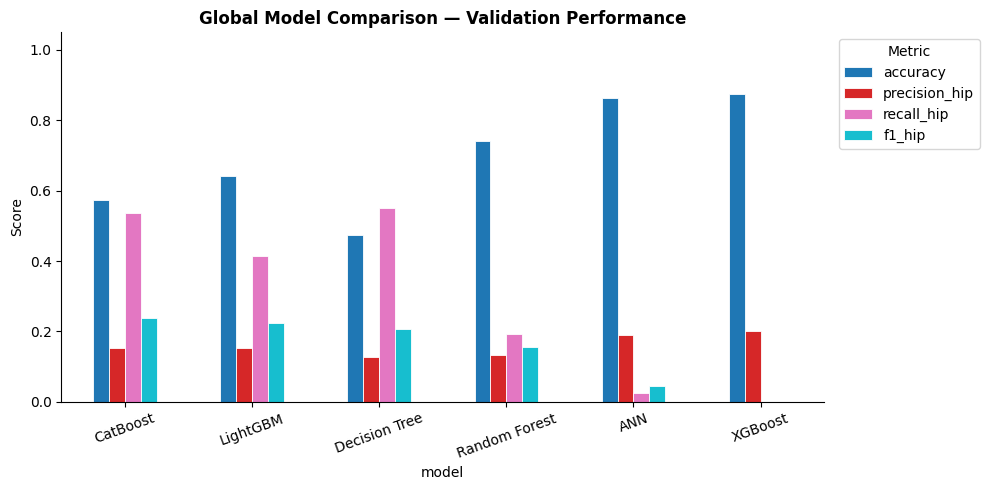

In [21]:
global_results_df = (
    pd.DataFrame(global_results)
    .set_index('model')
    .sort_values('f1_hip', ascending=False)
)
print('Global model performance on validation set (all 200 batters combined):')
print('=' * 65)
print(global_results_df.round(4).to_string())
print('=' * 65)

fig, ax = plt.subplots(figsize=(10, 5))
global_results_df[['accuracy','precision_hip','recall_hip','f1_hip']].plot(
    kind='bar', ax=ax, edgecolor='white', linewidth=0.6, colormap='tab10', rot=20
)
ax.set_title('Global Model Comparison — Validation Performance', fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(title='Metric', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('global_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Per-Batter Breakdown — Best Global Model

The global model produces a single set of predictions across all batters. This section breaks those predictions down **per batter** to compare directly against the per-batter modeling approach's results (`multi_batter_results.csv` from the previous notebook).

In [22]:
# ── Identify best model by validation F1 ──────────────────────────────────────
best_model_name = global_results_df.index[0]
print(f'Best global model: {best_model_name}')

# Map model name -> (y_true, y_pred, batter_id_series)
if best_model_name in ['XGBoost', 'LightGBM', 'CatBoost']:
    y_true_best = y_val_native
    y_pred_best = {'XGBoost': y_pred_xgb_val, 'LightGBM': y_pred_lgbm_val,
                   'CatBoost': y_pred_cat_val}[best_model_name]
    minority_best = minority_native
    n_classes_best = len(classes_native)
    batter_ids_val = val_combined['batter'].values
else:
    y_true_best = y_val_oh
    y_pred_best = {'Decision Tree': y_pred_dt_val, 'Random Forest': y_pred_rf_val,
                   'ANN': y_pred_ann_val}[best_model_name]
    minority_best = minority_oh
    n_classes_best = len(classes_oh)
    batter_ids_val = val_combined['batter'].values

# All other (non-minority) encoded labels — handles binary case robustly
other_labels_best = [c for c in range(n_classes_best) if c != minority_best]

# ── Build batter -> team lookup from first_pitch_train ───────────────────────
# Batters batting in the Top half face the home team's pitcher, so they are
# on the AWAY team; Bottom half batters are on the HOME team.
def derive_batter_team(row):
    if row['inning_topbot'] == 'Top':
        return row['away_team']
    return row['home_team']

batter_team_map = (
    first_pitch_train[['batter', 'home_team', 'away_team', 'inning_topbot']]
    .dropna(subset=['home_team', 'away_team', 'inning_topbot'])
    .assign(team=lambda df: df.apply(derive_batter_team, axis=1))
    .groupby('batter')['team']
    .agg(lambda x: x.mode().iloc[0])   # most common team in training window
    .to_dict()
)

per_batter_rows = []
for bid in top_batter_ids:
    mask = (batter_ids_val == bid)
    if mask.sum() == 0:
        continue
    yt = y_true_best[mask]
    yp = y_pred_best[mask]
    prec, rec, f1 = minority_class_metrics(yt, yp, minority_best)

    # Confusion counts for the minority (hit_into_play) class
    yt_is_other = np.isin(yt, other_labels_best)
    predicted_hip_result_hip     = int(((yp == minority_best) & (yt == minority_best)).sum())  # TP
    predicted_hip_result_not_hip = int(((yp == minority_best) & yt_is_other).sum())            # FP

    per_batter_rows.append({
        'batter_id':   bid,
        'batter_name': name_map.get(int(bid), str(bid)),
        'team':        batter_team_map.get(bid, 'UNK'),
        'val_samples': int(mask.sum()),
        'val_hip':     int((yt == minority_best).sum()),
        'precision_hip': prec,
        'recall_hip':    rec,
        'f1_hip':        f1,
        'predicted_hip_result_hip':     predicted_hip_result_hip,
        'predicted_hip_result_not_hip': predicted_hip_result_not_hip,
    })

global_per_batter_df = pd.DataFrame(per_batter_rows)
global_per_batter_df.to_csv('global_model_per_batter_results.csv', index=False)

print(f'\nPer-batter results for {best_model_name} (global model):')
print(global_per_batter_df[['precision_hip','recall_hip','f1_hip']].mean().round(4).to_string())
print(f'\nSaved: global_model_per_batter_results.csv ({len(global_per_batter_df)} batters)')

Best global model: CatBoost

Per-batter results for CatBoost (global model):
precision_hip    0.1458
recall_hip       0.4950
f1_hip           0.2173

Saved: global_model_per_batter_results.csv (298 batters)


Comparison — Mean F1 (hit_into_play):
                 Per-Batter Models (mean F1)
model                                       
Decision Tree                         0.1703
ANN                                   0.1475
Random Forest                         0.1378
XGBoost                               0.1071
LightGBM                              0.1021
CatBoost                              0.0959
Global CatBoost                       0.2173


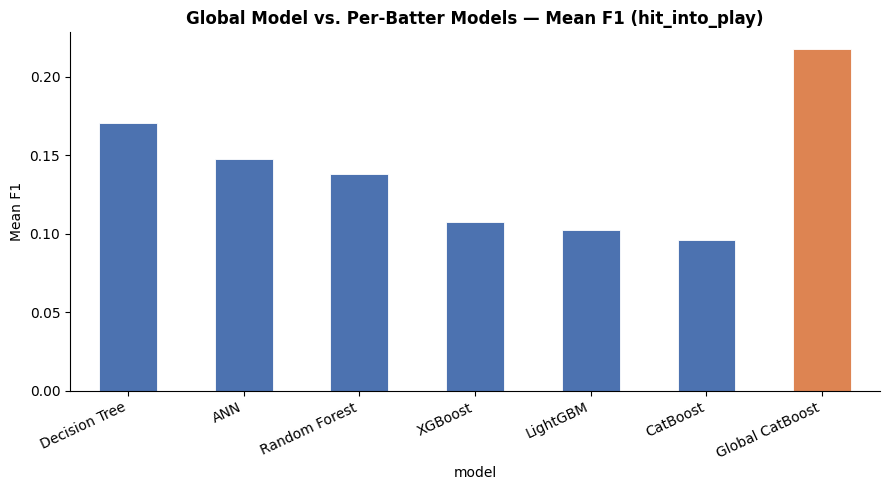

In [23]:
# ── Compare global model vs. per-batter models (if results CSV available) ────
import os

if os.path.exists('multi_batter_results.csv'):
    per_batter_results = pd.read_csv('multi_batter_results.csv')

    # Mean F1 per model from the per-batter approach
    per_batter_summary = (
        per_batter_results.groupby('model')['f1_hip']
        .mean()
        .sort_values(ascending=False)
    )

    comparison = pd.DataFrame({
        'Per-Batter Models (mean F1)': per_batter_summary,
    })
    comparison.loc[f'Global {best_model_name}'] = global_per_batter_df['f1_hip'].mean()

    print('Comparison — Mean F1 (hit_into_play):')
    print('=' * 50)
    print(comparison.round(4).to_string())
    print('=' * 50)

    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['#4C72B0'] * len(per_batter_summary) + ['#DD8452']
    comparison['Per-Batter Models (mean F1)'].plot(
        kind='bar', ax=ax, color=colors, edgecolor='white', linewidth=0.6
    )
    ax.set_title('Global Model vs. Per-Batter Models — Mean F1 (hit_into_play)',
                 fontweight='bold')
    ax.set_ylabel('Mean F1')
    ax.set_xticklabels(comparison.index, rotation=25, ha='right')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('global_vs_per_batter_f1.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('multi_batter_results.csv not found — run the per-batter notebook first '
          'to enable this comparison.')

## 11. Feature Importance — CatBoost

Shows where `batter_id` and the new batter-level tendency features rank relative to pitcher and game-state features.

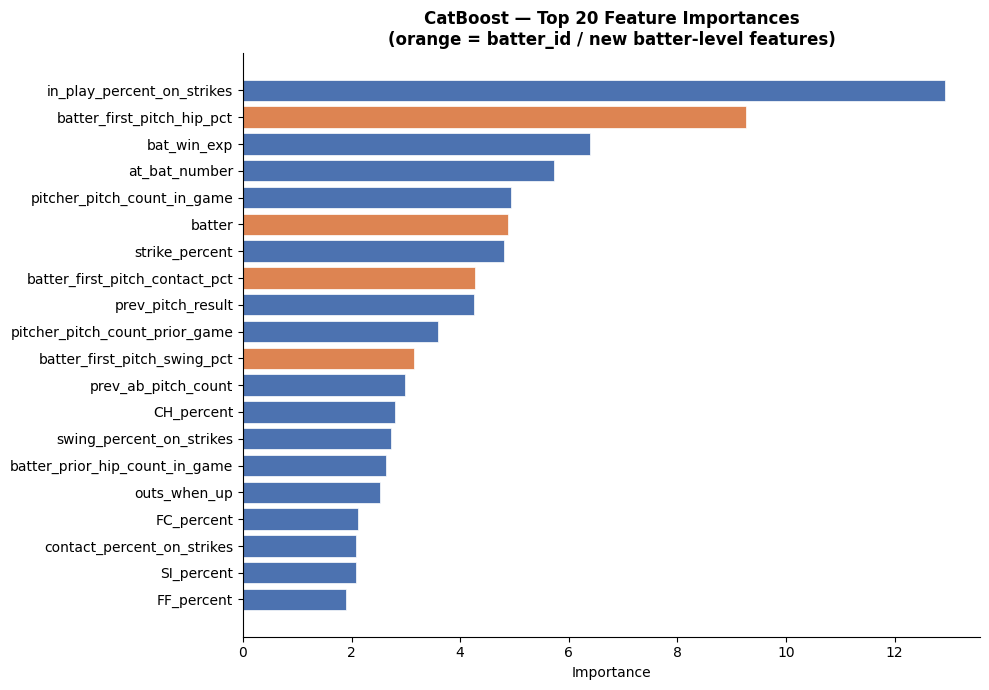

In [24]:
importances = cat_global.get_feature_importance()
feat_names  = list(X_train_native.columns)

imp_df = (
    pd.DataFrame({'feature': feat_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(20)
)

# Highlight the new batter-level and batter_id features
highlight = ['batter', 'batter_first_pitch_swing_pct',
              'batter_first_pitch_contact_pct', 'batter_first_pitch_hip_pct']
colors = ['#DD8452' if f in highlight else '#4C72B0' for f in imp_df['feature']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
        color=colors[::-1], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Importance')
ax.set_title('CatBoost — Top 20 Feature Importances\n'
             '(orange = batter_id / new batter-level features)',
             fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('global_catboost_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Skipped Batters Report

In [25]:
if skipped:
    skip_df = pd.DataFrame(skipped, columns=['batter_id', 'batter_name', 'reason'])
    print(f'{len(skip_df)} (batter, dataset) combinations skipped:')
    print(skip_df.to_string(index=False))
else:
    print('No batters skipped.')

2 (batter, dataset) combinations skipped:
 batter_id   batter_name           reason
    672279 Michael Siani val: only 1 rows
    691019     Kyle Teel val: only 4 rows
